## Free Fall as a System of First-Order ODEs

The motion of a particle under gravity is described by the second-order differential equation:

\[
\frac{d^2 x}{dt^2} = -g
\]

where:
- \( x(t) \) is the position  
- \( g \) is the acceleration due to gravity  



The numerical solvers  Euler and Runge–Kutta methods are designed to solve first-order equations of the form:

\[
\frac{dy}{dt} = f(t, y)
\]

So to use these methods for this problem , we need to convert the second-order equation into a system of first-order equations.

We know that 

\[
\frac{dx}{dt} = v
\]
\[
\frac{dv}{dt} = -g
\]

So we can define a vector

\[
y =
\begin{bmatrix}
x \\
v
\end{bmatrix}
\]

So the system becomes,

\[
\frac{dy}{dt} =
\begin{bmatrix}
v \\
-g
\end{bmatrix}
\]

Now we can  use standard ODE solvers by making position and velocity as components of a single vector.




In [258]:
import sys
import os

sys.path.append("../src")
from euler import EulerODE
from rkmethods import rk4
from rkmethods import rk5

import numpy as np
import matplotlib.pyplot as plt

# freefall function

def f(t,y):

    # x : position
    # v : velocity
    # g : acceleration due to gravity
    # returns dx/dt and dv/dt

    x,v = y  # takes y = [x,v] 

    return np.array([v,-g])

g = 9.81
x = 0 # initial position
v = 14 # initial velocity
y0 = np.array([x, v])  #  starting point
t0 = 0
h = 0.01
n = 500

t_1, y_1 = EulerODE(f, t0, y0, n, h)
t_2, y_2 = rk4(f, t0, y0, n, h)
t_3, y_3 = rk5(f, t0, y0, n, h)

# now the solvers return us with the vector y with x and v 

x1,v1 = y_1[:,0],y_1[:,1]  # taking values of x and v using ':'  take all rows from colomn 0 and 1
x2,v2 = y_2[:,0],y_2[:,1] 
x3,v3 = y_3[:,0],y_3[:,1] 













Now we can compare this with exact value.

The analytical solution is

\[
x(t) = x_0 + v_0 t - \frac{1}{2} g t^2
\]

\[
v(t) = v_0 - g t
\]


In [259]:
t = t_1  # same grid

x_exact = x + v*t - 0.5*g*t**2
v_exact = v - g*t

We can plot the position vs time graph for free fall

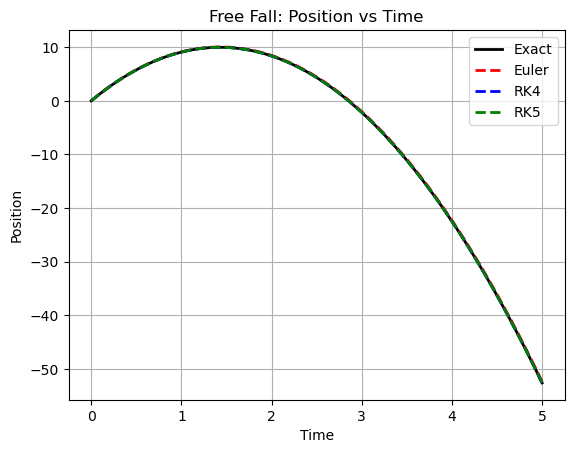

In [260]:
plt.plot(t, x_exact, color='black', label='Exact')
plt.plot(t_1, x1, 'r--', label='Euler')
plt.plot(t_2, x2, 'b--', label='RK4')
plt.plot(t_3, x3, 'g--', label='RK5')

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Free Fall: Position vs Time")
plt.legend()
plt.grid()
plt.show()

We can also plot Position vs velocity (phase plot)

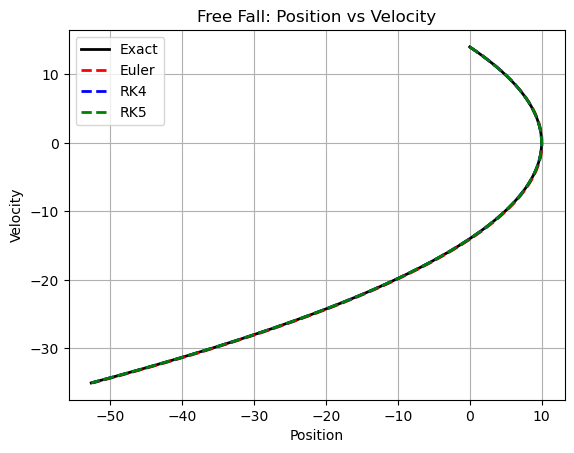

In [261]:
plt.plot(x_exact, v_exact, color='black', label='Exact')
plt.plot(x1, v1, 'r--', label='Euler')
plt.plot(x2, v2, 'b--', label='RK4')
plt.plot(x3, v3, 'g--', label='RK5')

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Free Fall: Position vs Velocity")
plt.legend()
plt.grid()
plt.show()

Still all the methods are alinged. So now we can try to find the error in this calculation.

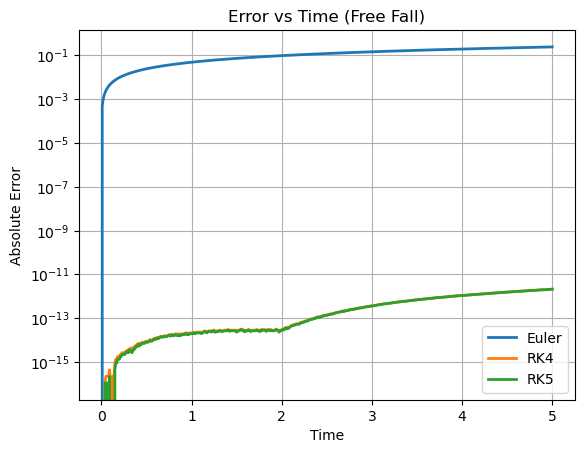

In [262]:
error_euler = np.abs(x1 - x_exact) 
error_rk4 = np.abs(x2 - x_exact)
error_rk5 = np.abs(x3 - x_exact)

plt.plot(t, error_euler, label="Euler")
plt.plot(t, error_rk4, label="RK4")
plt.plot(t, error_rk5, label="RK5")

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error vs Time (Free Fall)")
plt.legend()
plt.grid()
plt.show()

The error is low in RK methods compared to Euler in freefall calculations.

We have not yet considered air resistance in our calculations.

## Free Fall with Air Resistance

In realistic scenarios, an object moving through a fluid (such as air) experiences a resistive force known as drag. This force opposes the motion and modifies the equations of motion.


The general equation for motion under gravity with drag is:

\[
\frac{d^2 x}{dt^2} = -g + \frac{F_d}{m}
\]

where:
- \( g \) is the acceleration due to gravity  
- \( F_d \) is the drag force  
- \( m \) is the mass of the object  


For low velocities, drag is often modeled as proportional to velocity:

\[
F_d = -k v
\]

Substituting into the equation of motion:

\[
\frac{dv}{dt} = -g - \frac{k}{m} v
\]

The system of first-order equations becomes:

\[
\frac{dx}{dt} = v
\]
\[
\frac{dv}{dt} = -g - \frac{k}{m} v
\]



For higher velocities, drag is better approximated as proportional to the square of velocity:

\[
F_d = -k v |v|
\]

This ensures that the drag force always opposes the direction of motion.

The equation of motion becomes:

\[
\frac{dv}{dt} = -g - \frac{k}{m} v |v|
\]

The corresponding system is:

\[
\frac{dx}{dt} = v
\]
\[
\frac{dv}{dt} = -g - \frac{k}{m} v |v|
\]



### Terminal Velocity

Terminal velocity is the constant velocity reached when the drag force balances gravity, causing acceleration to become zero and preventing further increase in speed
In both models, the object eventually reaches a constant velocity when acceleration becomes zero:

\[
\frac{dv}{dt} = 0
\]

#### Linear Drag:
\[
v_{\text{terminal}} = -\frac{mg}{k}
\]

#### Quadratic Drag:
\[
v_{\text{terminal}} = -\sqrt{\frac{mg}{k}}
\]




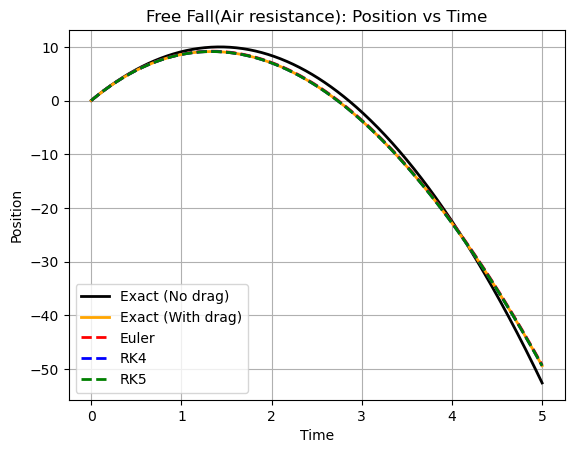

In [263]:
# Function with linear air resistance 
# freefall function

def f(t,y):

    # x : position
    # v : velocity
    # g : acceleration due to gravity
    # returns dx/dt and dv/dt
    # k : drag constant
    x,v = y  # takes y = [x,v] 

    return np.array([v,-g-k*v]) # varying k on our own and taking the mass m = 1 (or k = k/m as effective parameter)

g = 9.81
k = 0.1
x = 0.0 # initial position
v = 14.0 # initial velocity
y0 = np.array([x, v])  #  starting point
t0 = 0
h = 0.01
n = 500

t1, y1 = EulerODE(f, t0, y0, n, h)
t2, y2 = rk4(f, t0, y0, n, h)
t3, y3 = rk5(f, t0, y0, n, h)

x1,v1 = y1[:,0],y1[:,1] 
x2,v2 = y2[:,0],y2[:,1] 
x3,v3 = y3[:,0],y3[:,1] 


# exact position with drag 
t = t1
xexact = x - (g/k)*t + (1/k)*(v + g/k)*(1 - np.exp(-k*t))

x_exact = x + v*t - 0.5*g*t**2
v_exact = v - g*t

plt.plot(t1, x_exact, 'k-', label='Exact (No drag)')
plt.plot(t1, xexact,color='orange', label='Exact (With drag)')
plt.plot(t1, x1, 'r--', label='Euler')
plt.plot(t2, x2, 'b--', label='RK4')
plt.plot(t3, x3, 'g--', label='RK5')

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Free Fall(Air resistance): Position vs Time")
plt.legend()
plt.grid()
plt.show()

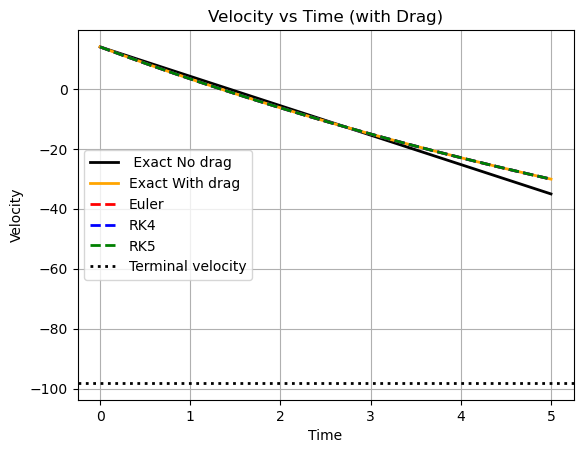

In [264]:
t = t2  # or any time array
v_exact = v - g*t

#exact velocity with drag
vexact = -g/k + (v + g/k)*np.exp(-k*t)

plt.plot(t1, v_exact, 'k-', label=' Exact No drag')
plt.plot(t1, vexact, color ='orange', label='Exact With drag')
plt.plot(t1, v1, 'r--', label='Euler')
plt.plot(t2, v2, 'b--', label='RK4')
plt.plot(t3, v3, 'g--', label='RK5')

#terminal velocity
v_term = -g/k
plt.axhline(v_term, color='black', linestyle=':', label='Terminal velocity')

plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Velocity vs Time (with Drag)")
plt.legend()
plt.grid()
plt.show()

All three numerical methods (Euler, RK4, and RK5) show excellent agreement with the analytical solution for free fall with linear drag when a sufficiently small step size is used.

Having validated the accuracy of the numerical solvers, we now investigate how varying the drag coefficient k influences the dynamics of free fall. 

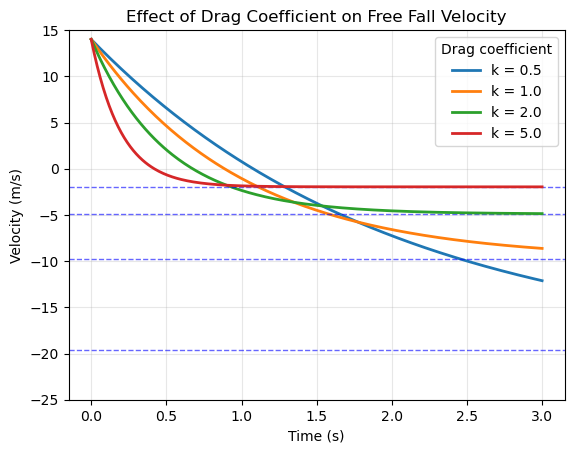

In [265]:

g = 9.81
ks = [0.5, 1.0, 2.0, 5.0]
t_max = 3
h = 0.01
x = 0.0 # initial position
v = 14.0 # initial velocity
y0 = np.array([x, v])  #  starting point
t0 = 0
for k in ks:
   n = int(t_max/h)
   t, y = rk4(f, 0, y0, n, h)
   v = y[:,1]
   v_term = -g/k
   plt.axhline(v_term, linestyle='--', linewidth=1, alpha=0.6)
   plt.plot(t, v, linewidth=2, label=f"k = {k}")


plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Effect of Drag Coefficient on Free Fall Velocity")

plt.ylim(-25, 15)
plt.grid(alpha=0.3)
plt.legend(title="Drag coefficient")
plt.show()
    

We can see that increasing the drag coefficient leads to faster convergence to terminal velocity while reducing its magnitude. Stronger drag forces damp the motion more rapidly, causing the system to reach steady-state behavior sooner.

Lets now try quadratic too

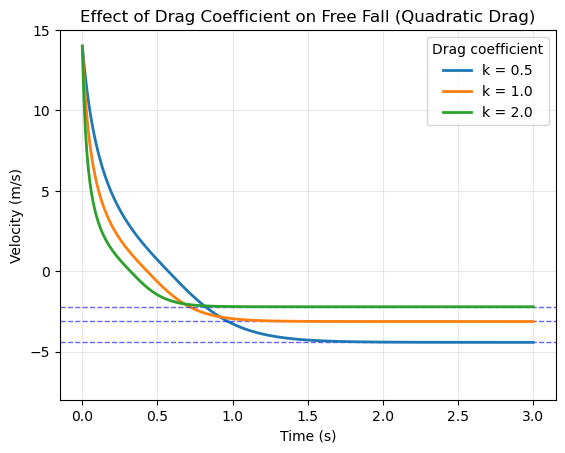

In [266]:
def f(t,y):

    # x : position
    # v : velocity
    # g : acceleration due to gravity
    # returns dx/dt and dv/dt

    x,v = y  # takes y = [x,v] 

    return np.array([v, -g - k*v*abs(v)])

ks = [0.5, 1.0, 2.0]
t_max = 3
g = 9.81
x = 0 # initial position
v = 14 # initial velocity
y0 = np.array([x, v])  #  starting point
t0 = 0
h = 0.01


for k in ks:
   n = int(t_max/h)
   t, y = rk4(f, 0, y0, n, h)
   v = y[:,1]
   v_term = -np.sqrt(g/k) # terminal velocity for quadratic
   plt.axhline(v_term, linestyle='--', linewidth=1, alpha=0.6)
   plt.plot(t, v, linewidth=2, label=f"k = {k}")


plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Effect of Drag Coefficient on Free Fall (Quadratic Drag)")

plt.ylim(-8, 15)
plt.grid(alpha=0.3)
plt.legend(title="Drag coefficient")
plt.show()
    


